In [2]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Forecasts: DE_load_forecast_entsoe_transparency (demand), solar_forecast_MW, wind_forecast_MW

Actual generation: DE_solar_generation_actual, DE_wind_onshore_generation_actual

Price: DE_LU_price_day_ahead

Derived features:

residual_load = net load after renewable contribution

Lagged prices (price_lag1, price_lag24)

We use lagged prices and forecasts to capture both temporal correlations and nonlinear effects of supply & demand on prices.

In [3]:
df = pd.read_csv("D:\\Quant\\battery dispatch optimisation\\battery-dispatch-optimisation\\data\\raw\\opsd-time_series-2020-10-06\\time_series_60min_singleindex.csv")
#df = pd.read_csv("D:\\Quant\\battery dispatch optimisation\\battery-dispatch-optimisation\\data\\raw\\1.csv")

In [4]:
df = df[['DE_load_forecast_entsoe_transparency', 'DE_solar_profile', 'DE_wind_onshore_profile', 'DE_LU_price_day_ahead', 'DE_load_actual_entsoe_transparency', 'DE_solar_generation_actual', 'DE_wind_onshore_generation_actual',  'cet_cest_timestamp', 'DE_wind_onshore_capacity', 'DE_solar_capacity']]
df['date'] = pd.to_datetime(df['cet_cest_timestamp'], utc=True) 
df = df[df['date'] > pd.Timestamp('2018-01-01', tz='UTC')]
df = df.reset_index()
df = df.drop(columns=['index'])

In [5]:
core_cols = [
    'DE_LU_price_day_ahead', 
    'DE_solar_profile', 
    'DE_wind_onshore_profile',
    'DE_solar_capacity',
    'DE_wind_onshore_capacity',
    'DE_load_forecast_entsoe_transparency'
]

df = df.dropna(subset=core_cols)

df = df.set_index('date').asfreq('H')  # creates a perfectly hourly index
df.reset_index(inplace=True)
df = df.sort_values('date')
df['delta'] = df['date'].diff()
hourly = pd.Timedelta(hours=1)
all_hourly = (df['delta'][1:] == hourly).all() 
print("All timestamps are hourly:", all_hourly)
df = df.set_index('date').asfreq('H')
df = df.ffill()

All timestamps are hourly: True


C:\Users\kashy\AppData\Local\Temp\ipykernel_49696\438237280.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.set_index('date').asfreq('H')  # creates a perfectly hourly index
C:\Users\kashy\AppData\Local\Temp\ipykernel_49696\438237280.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.set_index('date').asfreq('H')


In [6]:
df['solar_forecast_MW'] = df['DE_solar_profile'] * df['DE_solar_capacity']
df['wind_forecast_MW']  = df['DE_wind_onshore_profile'] * df['DE_wind_onshore_capacity']

df['residual_load'] = df['DE_load_forecast_entsoe_transparency'] - (df['solar_forecast_MW'] + df['wind_forecast_MW'])

In [7]:
df.head()

,DE_load_forecast_entsoe_transparency,DE_solar_profile,DE_wind_onshore_profile,DE_LU_price_day_ahead,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_onshore_generation_actual,cet_cest_timestamp,DE_wind_onshore_capacity,DE_solar_capacity,delta,solar_forecast_MW,wind_forecast_MW,residual_load
date,,,,,,,,,,,,,,
2018-09-30 23:00:00+00:00,42760.0,0.0,0.0915,56.10,42126.0,0.0,3959.0,2018-10-01T01:00:00+0200,43243.0,46099.0,NaT,0.0,3956.7345,38803.2655
2018-10-01 00:00:00+00:00,42240.0,0.0,0.0896,51.41,41500.0,0.0,3876.0,2018-10-01T02:00:00+0200,43243.0,46099.0,0 days 01:00:00,0.0,3874.5728,38365.4272
2018-10-01 01:00:00+00:00,42609.0,0.0,0.0958,47.38,42353.0,0.0,4141.0,2018-10-01T03:00:00+0200,43243.0,46099.0,0 days 01:00:00,0.0,4142.6794,38466.3206
2018-10-01 02:00:00+00:00,44296.0,0.0,0.1060,47.59,43802.0,0.0,4582.0,2018-10-01T04:00:00+0200,43243.0,46099.0,0 days 01:00:00,0.0,4583.7580,39712.2420
2018-10-01 03:00:00+00:00,48426.0,0.0,0.1203,51.61,48065.0,0.0,5203.0,2018-10-01T05:00:00+0200,43243.0,46099.0,0 days 01:00:00,0.0,5202.1329,43223.8671


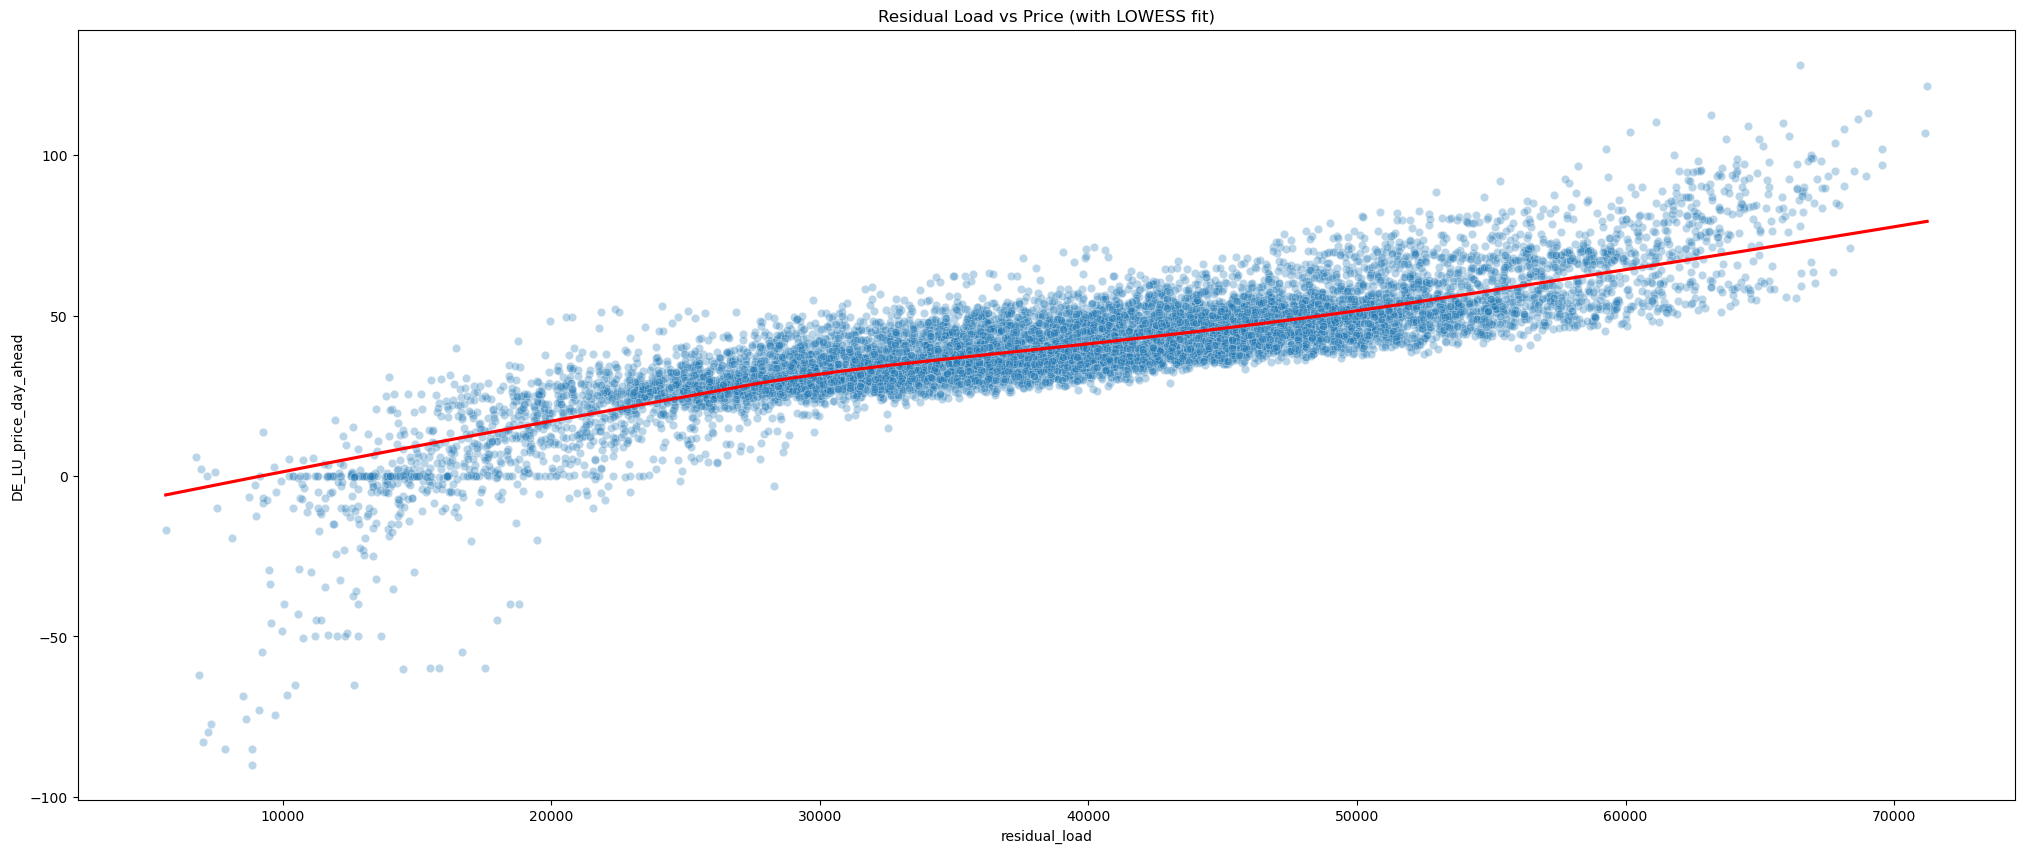

"Left tail (low residual load → high renewables)\nPrices collapse (sometimes even go negative) when wind + solar cover most of the load.\nThat's the tail you saw on the left.\n\nMiddle (normal residual load)\nPrices hover around “average marginal cost” of mid-merit plants (gas, coal).\nThat's the flat-ish central section of the S.\n\nRight head (high residual load → low renewables, high demand)\nPrices shoot up sharply because you're calling on expensive peakers.\nThat's the head on the right."

In [8]:
plt.figure(figsize=(25,10))
sns.scatterplot(
    data=df, 
    x='residual_load', 
    y='DE_LU_price_day_ahead', 
    alpha=0.3
)
sns.regplot(
    data=df, 
    x='residual_load', 
    y='DE_LU_price_day_ahead', 
    scatter=False, 
    lowess=True, 
    color='red'
)
plt.title("Residual Load vs Price (with LOWESS fit)")
plt.show()

'''Left tail (low residual load → high renewables)
Prices collapse (sometimes even go negative) when wind + solar cover most of the load.
That's the tail you saw on the left.

Middle (normal residual load)
Prices hover around “average marginal cost” of mid-merit plants (gas, coal).
That's the flat-ish central section of the S.

Right head (high residual load → low renewables, high demand)
Prices shoot up sharply because you're calling on expensive peakers.
That's the head on the right.'''

<Axes: xlabel='date'>

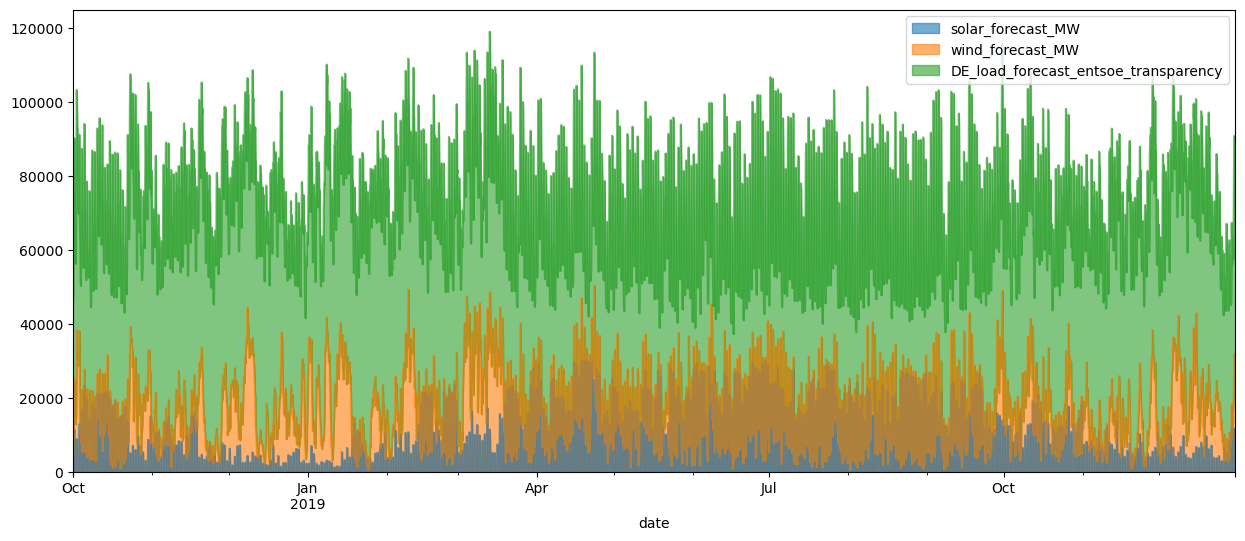

In [9]:
##Generation mix (stacked area chart)
##Show solar, wind, and load together.

df[['solar_forecast_MW','wind_forecast_MW','DE_load_forecast_entsoe_transparency']].plot.area(figsize=(15,6), alpha=0.6)

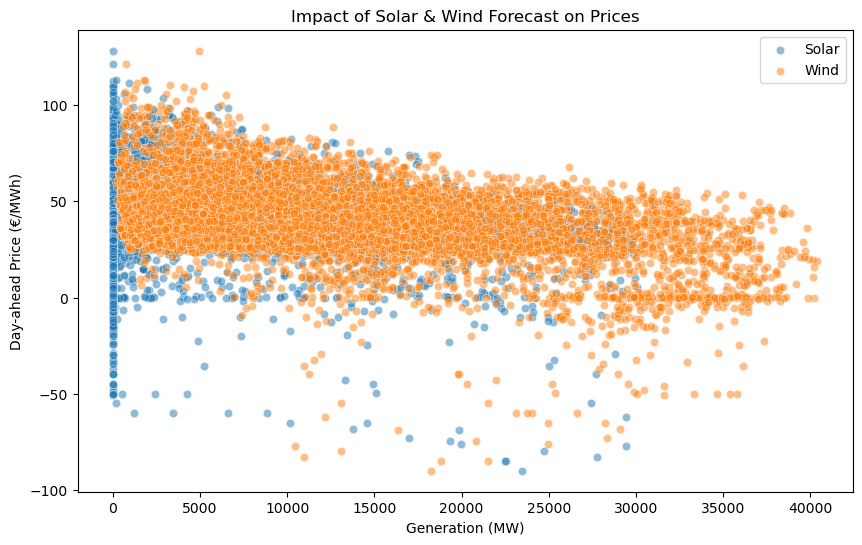

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='solar_forecast_MW', 
    y='DE_LU_price_day_ahead', 
    alpha=0.5, 
    label='Solar'
)

sns.scatterplot(
    data=df, 
    x='wind_forecast_MW', 
    y='DE_LU_price_day_ahead', 
    alpha=0.5, 
    label='Wind'
)

plt.xlabel("Generation (MW)")
plt.ylabel("Day-ahead Price (€/MWh)")
plt.title("Impact of Solar & Wind Forecast on Prices")
plt.legend()
plt.show()


In [13]:
df.columns

Index(['DE_load_forecast_entsoe_transparency', 'DE_solar_profile',
       'DE_wind_onshore_profile', 'DE_LU_price_day_ahead',
       'DE_load_actual_entsoe_transparency', 'DE_solar_generation_actual',
       'DE_wind_onshore_generation_actual', 'cet_cest_timestamp',
       'DE_wind_onshore_capacity', 'DE_solar_capacity', 'delta',
       'solar_forecast_MW', 'wind_forecast_MW', 'residual_load'],
      dtype='object')

## Predictive Model

We use XGBoost regression to predict the next-hour price:

Captures nonlinear relationships (e.g., high solar generation → lower prices; high residual load → higher prices).

Includes lagged prices to model market autocorrelation.

Result: for each hour, we get a predicted day-ahead price

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# create lag features
df['price_lag1'] = df['DE_LU_price_day_ahead'].shift(1)
df['price_lag24'] = df['DE_LU_price_day_ahead'].shift(24)

df = df.dropna()  # drop rows where lags are NaN

features = [
    'DE_load_forecast_entsoe_transparency',
    'solar_forecast_MW',
    'wind_forecast_MW',
    'residual_load',
    'price_lag1',
    'price_lag24'
]

target = 'DE_LU_price_day_ahead'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# XGBoost nonlinear regression
model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MAE: 3.4721577814767217
R²: 0.8859894021507035


In [15]:
df_test = df.loc[X_test.index].copy()
df_test['predicted_price'] = y_pred
df_test['signal'] = (df_test['predicted_price'] > df_test['price_lag1']).astype(int)
# 1 = discharge, 0 = charge

We simulate a battery operator that trades based on predicted prices:

Buy/charge: when predicted price is low (bottom 20% quantile).

Sell/discharge: when predicted price is high (top 20% quantile).

Do nothing: if predicted price is in the middle range → reduces over-trading.

Battery state-of-charge (SOC) is tracked to prevent overcharging or over-discharging.

Efficiency is included to account for energy losses when charging/discharging.

This is essentially a rule-based arbitrage strategy: buy low, sell high, constrained by the battery.

## PnL Simulation

We compute profit/loss per hour:

Charging → cost = - price * energy charged

Discharging → revenue = price * energy discharged

Cumulative PnL = sum over time

Plotting SOC vs cumulative PnL:

Shows how battery energy is being used over time

Shows overall profitability of the strategy

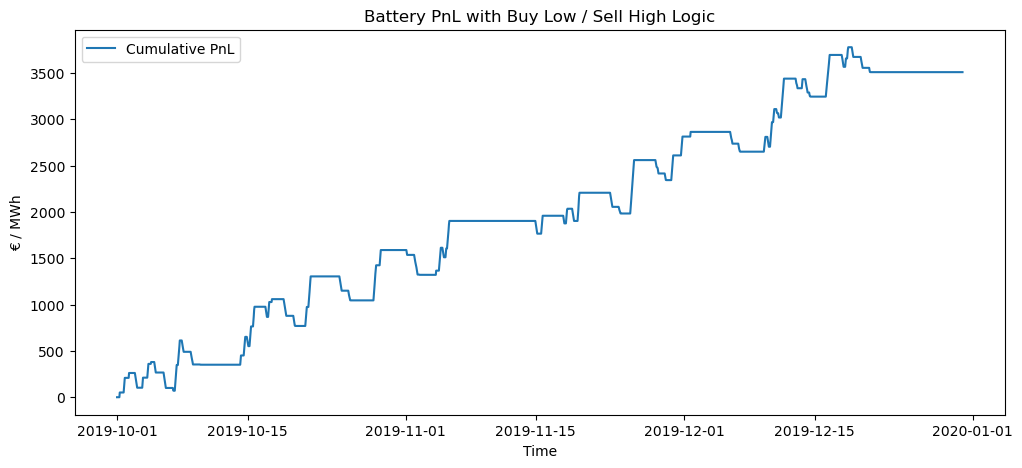

In [22]:
battery_capacity = 10  # MWh
charge_rate = 1        # MW
efficiency = 0.9
soc = 5  # start 50%

# smooth predictions
df_test['predicted_price_smooth'] = df_test['predicted_price'].rolling(3, center=True).mean()

# thresholds
low_thresh = df_test['predicted_price_smooth'].quantile(0.2)
high_thresh = df_test['predicted_price_smooth'].quantile(0.8)

# trading signals
df_test['signal'] = -1  # do nothing
df_test.loc[df_test['predicted_price_smooth'] < low_thresh, 'signal'] = 1   # charge
df_test.loc[df_test['predicted_price_smooth'] > high_thresh, 'signal'] = 0  # discharge

# simulate PnL
pnl = []
soc_list = []

for _, row in df_test.iterrows():
    price = row['DE_LU_price_day_ahead']
    sig = row['signal']
    
    if sig == 1 and soc < battery_capacity:  # charge
        charge = min(charge_rate, battery_capacity - soc)
        soc += charge * efficiency
        pnl.append(-charge * price)
    elif sig == 0 and soc > 0:  # discharge
        discharge = min(charge_rate, soc)
        soc -= discharge
        pnl.append(discharge * price)
    else:
        pnl.append(0)
    
    soc_list.append(soc)

df_test['pnl'] = pnl
df_test['cumulative_pnl'] = df_test['pnl'].cumsum()
df_test['soc'] = soc_list

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(df_test['cumulative_pnl'], label='Cumulative PnL')
plt.title("Battery PnL with Buy Low / Sell High Logic")
plt.xlabel("Time")
plt.ylabel("€ / MWh")
plt.legend()
plt.show()


## Key Insights

Model captures patterns: residual load and lagged prices predict price fluctuations.

Battery constraints matter: naive buy/sell logic loses money without SOC and efficiency.

Thresholds reduce noise: only trading on strong signals prevents negative PnL.

Visualizations: cumulative PnL and SOC charts make your strategy tangible for interviews.

Experimentation: you can show “flipped logic” (buy high / sell low) as an example of a negative-control test — demonstrates understanding of trading intuition.